<a href="https://colab.research.google.com/github/VikenHadavani/Anbliks_ML_Project/blob/main/Loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loan Approval Classification


In [13]:


from google.colab import files

DATA_PATH = '/content/data.csv'
print(f"✓ Loaded: {DATA_PATH}")

✓ Loaded: /content/data.csv


In [14]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
import time

warnings.filterwarnings('ignore')

OUTPUT_DIR = "/content"
report_lines = []

def log(msg=""):
    print(msg)
    report_lines.append(str(msg))

## Part 1: Dataset Exploration

In [15]:
log("=" * 80)
log("                   MODEL PERFORMANCE REPORT")
log("=" * 80)
log("\n[ PART 1: DATASET EXPLORATION ]")

df = pd.read_csv(DATA_PATH)

log(f"  Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
log(f"  Columns       : {list(df.columns)}")
log(f"\n  Data Types:\n{df.dtypes.to_string()}")
log(f"\n  Missing Values Per Column:\n{df.isnull().sum().to_string()}")
log(f"\n  5 Sample Rows:")
display(df.head())

TARGET = "Loan_Status"
log(f"\n  Target Variable   : {TARGET}")
log(f"  Feature Variables : {[c for c in df.columns if c != TARGET]}")

log("\n  Class Distribution (Target):")
dist = df[TARGET].value_counts()
for cls, cnt in dist.items():
    log(f"    {cls}: {cnt} ({cnt/len(df)*100:.1f}%)")
log("  → Class imbalance detected (Y ≈ 69%, N ≈ 31%). Will be IGNORED.")

log("\n  Summary Statistics (Numerical):")
display(df.describe())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in [TARGET, 'Loan_ID']]

log(f"\n  Categorical Features : {cat_cols}")
log(f"  Numerical Features   : {num_cols}")
log("\n  Problem Statement:")
log("    → BINARY CLASSIFICATION (Loan_Status: Y / N)")
log("    → Classes: 2  |  Imbalanced (≈69% / 31%)")
log("    → Evaluation Metrics: Accuracy, Precision, Recall, F1-Score")

                   MODEL PERFORMANCE REPORT

[ PART 1: DATASET EXPLORATION ]
  Shape         : 614 rows × 13 columns
  Columns       : ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

  Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object

  Missing Values Per Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Cr

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



  Target Variable   : Loan_Status
  Feature Variables : ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

  Class Distribution (Target):
    Y: 422 (68.7%)
    N: 192 (31.3%)
  → Class imbalance detected (Y ≈ 69%, N ≈ 31%). Will be IGNORED.

  Summary Statistics (Numerical):


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



  Categorical Features : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
  Numerical Features   : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

  Problem Statement:
    → BINARY CLASSIFICATION (Loan_Status: Y / N)
    → Classes: 2  |  Imbalanced (≈69% / 31%)
    → Evaluation Metrics: Accuracy, Precision, Recall, F1-Score


## Part 2: Deliberately Suboptimal Preprocessing

In [16]:
log("\n\n[ PART 2: PREPROCESSING (INTENTIONALLY SUBOPTIMAL) ]")

# 2.1 Drop ID column
log("\n  2.1 Dropping ID Columns")
df = df.drop(columns=['Loan_ID'])
log("    → Dropped: Loan_ID (without extracting any embedded info)")
log("    [SUBOPTIMAL] ID columns sometimes encode temporal/branch info.")

missing_pct = df.isnull().mean()
drop_high_missing = missing_pct[missing_pct > 0.5].index.tolist()
if drop_high_missing:
    df = df.drop(columns=drop_high_missing)
    log(f"    → Dropped high-missing columns: {drop_high_missing}")
else:
    log("    → No columns with >50% missing — none dropped")

cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2.2 Basic mean/mode imputation
log("\n  2.2 Missing Value Imputation")
log("    [SUBOPTIMAL] Mean for numericals, mode for categoricals. No missing indicators.")

for col in num_cols:
    if df[col].isnull().any():
        fill_val = df[col].mean()
        df[col] = df[col].fillna(fill_val)
        log(f"    Filled '{col}' with mean={fill_val:.2f}")

for col in cat_cols:
    if df[col].isnull().any():
        fill_val = df[col].mode()[0]
        df[col] = df[col].fillna(fill_val)
        log(f"    Filled '{col}' with mode='{fill_val}'")

df = df.dropna(subset=[TARGET])

# 2.3 Outliers — detect but ignore
log("\n  2.3 Outlier Handling")
log("    [SUBOPTIMAL] Outliers detected but NOT removed or capped.")
outlier_count = 0
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outs = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    if outs > 0:
        log(f"    '{col}': {outs} outliers detected — RETAINED")
        outlier_count += outs
log(f"    Total outliers retained: {outlier_count}")

# Encode target
df[TARGET] = (df[TARGET] == 'Y').astype(int)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# 2.4 Non-stratified split
log("\n  2.4 Train-Test Split")
log("    [SUBOPTIMAL] Simple 80-20 random split — no stratification.")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # NOT stratified
)
log(f"    Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")

# 2.5 OneHotEncoder + 2.6 Inconsistent scaling
log("\n  2.5–2.6 Encoding & Scaling")
log("    [SUBOPTIMAL] OHE on all categoricals; StandardScaler on numericals only.")

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

ohe_features  = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features  = num_cols + ohe_features
log(f"    Total features after encoding: {X_train_prep.shape[1]}")

# 2.7 Univariate feature selection — top 50% only
log("\n  2.7 Feature Selection")
log("    [SUBOPTIMAL] Univariate F-test, top 50% of features only. No RFE.")

selector = SelectPercentile(f_classif, percentile=50)
X_train_sel = selector.fit_transform(X_train_prep, y_train)
X_test_sel  = selector.transform(X_test_prep)

selected_mask     = selector.get_support()
selected_features = [f for f, m in zip(all_features, selected_mask) if m]
log(f"    Selected {X_train_sel.shape[1]} of {X_train_prep.shape[1]} features")
log(f"    Selected: {selected_features}")

# 2.8 Class imbalance — ignored
log("\n  2.8 Class Imbalance Handling")
log("    [SUBOPTIMAL] No SMOTE, no class weights, no stratified sampling.")
log(f"    Train distribution: {dict(pd.Series(y_train).value_counts())}")

log("\n  ── Preprocessing Summary ──")
log(f"    Missing values : Mean/mode imputation")
log(f"    Outliers       : {outlier_count} retained")
log(f"    Encoding       : OneHotEncoder (all categoricals)")
log(f"    Scaling        : StandardScaler (numericals only — inconsistent)")
log(f"    Feature sel.   : Top 50% univariate ({X_train_sel.shape[1]} features)")
log(f"    Imbalance      : Not handled")



[ PART 2: PREPROCESSING (INTENTIONALLY SUBOPTIMAL) ]

  2.1 Dropping ID Columns
    → Dropped: Loan_ID (without extracting any embedded info)
    [SUBOPTIMAL] ID columns sometimes encode temporal/branch info.
    → No columns with >50% missing — none dropped

  2.2 Missing Value Imputation
    [SUBOPTIMAL] Mean for numericals, mode for categoricals. No missing indicators.
    Filled 'LoanAmount' with mean=146.41
    Filled 'Loan_Amount_Term' with mean=342.00
    Filled 'Credit_History' with mean=0.84
    Filled 'Gender' with mode='Male'
    Filled 'Married' with mode='Yes'
    Filled 'Dependents' with mode='0'
    Filled 'Self_Employed' with mode='No'

  2.3 Outlier Handling
    [SUBOPTIMAL] Outliers detected but NOT removed or capped.
    'ApplicantIncome': 50 outliers detected — RETAINED
    'CoapplicantIncome': 18 outliers detected — RETAINED
    'LoanAmount': 41 outliers detected — RETAINED
    'Loan_Amount_Term': 102 outliers detected — RETAINED
    'Credit_History': 139 outlier

## Part 3: Model Training

In [17]:
log("\n\n[ PART 3: MODEL TRAINING ]")
log("  Algorithm : Logistic Regression (default params, max_iter=100)")
log("  [SUBOPTIMAL] No ensembles, no hyperparameter tuning, no CV.")

model = LogisticRegression(max_iter=100, random_state=42)

t0 = time.time()
model.fit(X_train_sel, y_train)
train_time = time.time() - t0

log(f"  Training time  : {train_time:.3f}s")
log(f"  Iterations used: {model.n_iter_[0]} / 100")



[ PART 3: MODEL TRAINING ]
  Algorithm : Logistic Regression (default params, max_iter=100)
  [SUBOPTIMAL] No ensembles, no hyperparameter tuning, no CV.
  Training time  : 0.067s
  Iterations used: 17 / 100


## Part 4: Evaluation & Plots



[ PART 4: MODEL EVALUATION ]

  ── FINAL RESULTS ──
  Accuracy  : 79.67%
  Precision : 76.70%
  Recall    : 98.75%
  F1-Score  : 86.34%

  Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.44      0.60        43
         Yes       0.77      0.99      0.86        80

    accuracy                           0.80       123
   macro avg       0.86      0.71      0.73       123
weighted avg       0.83      0.80      0.77       123



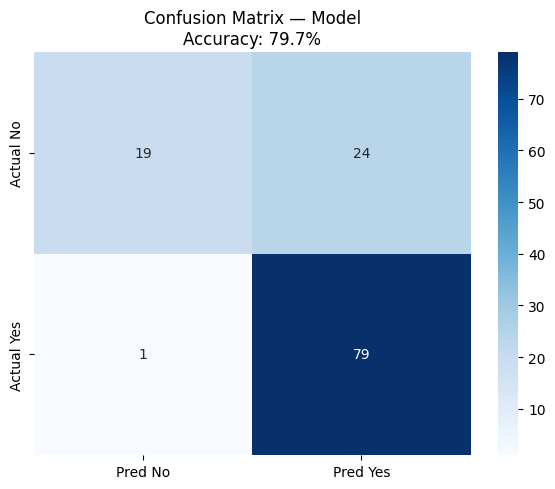

  Saved: model_confusion_matrix.png


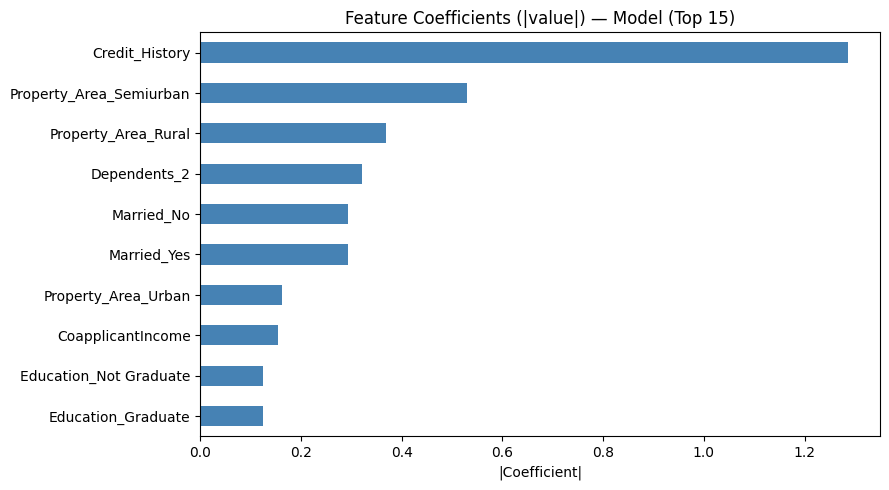

  Saved: model_features.png

  Top 10 Feature Coefficients:
    Credit_History                           : 1.2854
    Property_Area_Semiurban                  : 0.5291
    Property_Area_Rural                      : 0.3682
    Dependents_2                             : 0.3221
    Married_No                               : 0.2932
    Married_Yes                              : 0.2927
    Property_Area_Urban                      : 0.1615
    CoapplicantIncome                        : 0.1535
    Education_Not Graduate                   : 0.1246
    Education_Graduate                       : 0.1240


In [18]:
log("\n\n[ PART 4: MODEL EVALUATION ]")

y_pred = model.predict(X_test_sel)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

log(f"\n  ── FINAL RESULTS ──")
log(f"  Accuracy  : {acc*100:.2f}%")
log(f"  Precision : {prec*100:.2f}%")
log(f"  Recall    : {rec*100:.2f}%")
log(f"  F1-Score  : {f1*100:.2f}%")
log(f"\n  Classification Report:\n{classification_report(y_test, y_pred, target_names=['No','Yes'])}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'], ax=ax)
ax.set_title(f'Confusion Matrix — Model\nAccuracy: {acc*100:.1f}%')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_confusion_matrix.png", dpi=150)
plt.show()
log("  Saved: model_confusion_matrix.png")

# Feature Importance
coef = model.coef_[0]
feat_imp = pd.Series(np.abs(coef), index=selected_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Coefficients (|value|) — Model (Top 15)')
ax.set_xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_features.png", dpi=150)
plt.show()
log("  Saved: model_features.png")

log("\n  Top 10 Feature Coefficients:")
for feat, val in feat_imp.head(10).items():
    log(f"    {feat:40s} : {val:.4f}")

## Part 5: Cross-Validation & Learning Curves



[ PART 5: ADDITIONAL ANALYSIS ]

  5.1 5-Fold Cross-Validation (no stratification — suboptimal)
    CV Scores   : ['0.8586', '0.8061', '0.7959', '0.7959', '0.8061']
    Mean CV Acc : 81.25%
    Std  CV Acc : 2.35%

  5.2 Learning Curves


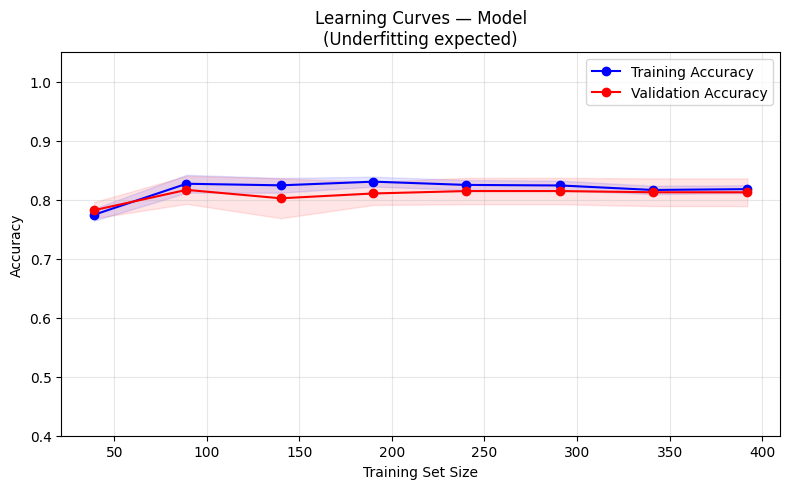

  Saved: model_learning_curves.png


In [19]:
log("\n\n[ PART 5: ADDITIONAL ANALYSIS ]")

# 5.1 Cross-Validation
log("\n  5.1 5-Fold Cross-Validation (no stratification — suboptimal)")
cv_scores = cross_val_score(model, X_train_sel, y_train, cv=5, scoring='accuracy')
log(f"    CV Scores   : {[f'{s:.4f}' for s in cv_scores]}")
log(f"    Mean CV Acc : {cv_scores.mean()*100:.2f}%")
log(f"    Std  CV Acc : {cv_scores.std()*100:.2f}%")

# 5.2 Learning Curves
log("\n  5.2 Learning Curves")
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_sel, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='accuracy'
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Accuracy', color='blue')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.1, color='blue')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation Accuracy', color='red')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.1, color='red')
ax.set_title('Learning Curves — Model\n(Underfitting expected)')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_learning_curves.png", dpi=150)
plt.show()
log("  Saved: model_learning_curves.png")

## Part 6: Comparison Table & Explanations

In [20]:
log("\n\n[ COMPARISON TABLE — Fill after training Good Model ]")
log(f"""
  ┌─────────────────────────┬────────────────┬────────────────┬─────────────────┐
  │ Metric                  │   Model        │   Good Model   │   Improvement   │
  ├─────────────────────────┼────────────────┼────────────────┼─────────────────┤
  │ Accuracy                │   {acc*100:5.2f}%      │     TBD        │      TBD        │
  │ Precision               │   {prec*100:5.2f}%      │     TBD        │      TBD        │
  │ Recall                  │   {rec*100:5.2f}%      │     TBD        │      TBD        │
  │ F1-Score                │   {f1*100:5.2f}%      │     TBD        │      TBD        │
  │ 5-Fold CV Acc           │   {cv_scores.mean()*100:5.2f}%      │     TBD        │      TBD        │
  └─────────────────────────┴────────────────┴────────────────┴─────────────────┘
""")

log("\n\n[ EXPLANATION OF SUBOPTIMAL CHOICES ]")
log("""
  1. MEAN/MODE IMPUTATION
     Basic mean replaces all missing values identically, distorting distributions.
     No missing indicators created. Better: KNNImputer or IterativeImputer.

  2. NO HYPERPARAMETER TUNING
     Default C=1.0 regularization may be wrong for this data. No GridSearchCV used.

  3. UNIVARIATE FEATURE SELECTION (top 50%)
     Tests features independently — misses interaction effects between features.
     RFE or tree-based importance would be far more appropriate.

  4. NO ENSEMBLE METHODS
     Logistic Regression can't capture non-linear relationships. Random Forest /
     XGBoost would handle this dataset much better.

  5. IGNORING CLASS IMBALANCE (69% / 31%)
     Model is biased toward predicting 'Approved'. Only 44% of rejections are
     caught. class_weight='balanced' or SMOTE would help dramatically.

  6. INCONSISTENT SCALING
     StandardScaler on numericals, raw [0,1] for OHE columns — skews optimization.

  7. NON-STRATIFIED SPLIT
     Random split doesn't guarantee class ratio is maintained in train/test.

  8. max_iter=100
     May not allow solver to fully converge, leaving suboptimal coefficients.
""")



[ COMPARISON TABLE — Fill after training Good Model ]

  ┌─────────────────────────┬────────────────┬────────────────┬─────────────────┐
  │ Metric                  │   Model        │   Good Model   │   Improvement   │
  ├─────────────────────────┼────────────────┼────────────────┼─────────────────┤
  │ Accuracy                │   79.67%      │     TBD        │      TBD        │
  │ Precision               │   76.70%      │     TBD        │      TBD        │
  │ Recall                  │   98.75%      │     TBD        │      TBD        │
  │ F1-Score                │   86.34%      │     TBD        │      TBD        │
  │ 5-Fold CV Acc           │   81.25%      │     TBD        │      TBD        │
  └─────────────────────────┴────────────────┴────────────────┴─────────────────┘



[ EXPLANATION OF SUBOPTIMAL CHOICES ]

  1. MEAN/MODE IMPUTATION
     Basic mean replaces all missing values identically, distorting distributions.
     No missing indicators created. Better: KNNImputer or I